# Phase 1.5 v8 — Ensemble Evaluation 4 변형 (`08_ensemble_evaluation.ipynb`)

> **목적**: v4 best LSTM + HAR-RV ensemble 의 효과 검증.
> 4 가지 가중치 변형 비교 → 최적 ensemble 발견.

## 4 Ensemble 변형

| 변형 | 가중치 결정 | 학술 근거 |
|---|---|---|
| **1. Simple** | 0.5 / 0.5 | Stock-Watson (2004) Forecast combination puzzle |
| **2. IVW** | 1/MSE 비율 | Bates-Granger (1969) |
| **3. Performance-Weighted** | 이전 fold OOS RMSE 비율 (rolling) | Diebold-Pauly (1987) |
| **4. Asset-Specific** | 종목별 RMSE 비율 | 본 프로젝트 v5 결과 활용 |

## 핵심 — **학습 X, GPU 불필요** ⭐

```
v4 best, HAR 의 fold_predictions: 이미 results/multi_asset/ 에 저장됨
→ 학습 X
→ 가중 평균만 계산 (수 초)
→ 메트릭 재계산 (수 초)
→ DM 검정 (수 초)

전체: ~5분 (CPU 만으로)
```

## 7 종목

SPY, QQQ, DIA, EEM, XLF, GOOGL, WMT

## 본 노트북 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 + 기존 v4/HAR 결과 로드 (multi_asset) |
| §2 | 4 변형 가중치 결정 함수 |
| §3 | 종목 × 변형별 ensemble 예측 계산 |
| §4 | 메트릭 계산 (5종) |
| §5 | v4 / HAR / 4 ensemble 비교 표 |
| §6 | DM 검정 (Ensemble vs v4, vs HAR) |
| §7 | 시각화 (5종 이상) |
| §8 | 결론 + 보고서 자동 생성 |


## §1. 환경 + 기존 결과 로드 (학습 X)


In [1]:
import sys
import json
import time
from pathlib import Path
import numpy as np
import pandas as pd

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

from scripts.setup import bootstrap, BASE_DIR, RAW_DATA_DIR, RESULTS_DIR
font_used = bootstrap()

TICKERS = ['SPY', 'QQQ', 'DIA', 'EEM', 'XLF', 'GOOGL', 'WMT']

# 1) LSTM v4 fold_predictions 로드 (multi_asset 의 fold_predictions_lstm)
V4_DIR = RESULTS_DIR / 'multi_asset'
lstm_v4_folds_dict = {}
for tk in TICKERS:
    with open(V4_DIR / f'{tk}_v4_metrics.json', 'r', encoding='utf-8') as f:
        data = json.load(f)
    lstm_v4_folds_dict[tk] = data['fold_predictions_lstm']
    print(f'  [{tk}] LSTM v4: {len(lstm_v4_folds_dict[tk])} fold 로드')

# 2) HAR 은 fold 별 y_pred 가 multi_asset JSON 에 저장 안 됨 → 재계산 필요
# 본 §1 다음 §1.5 에서 raw_data + Walk-Forward + HAR 재학습
print()
print('HAR fold_predictions 는 multi_asset JSON 에 미저장 → §1.5 에서 재계산 (~30초 CPU)')


  Phase 1 — 환경 부트스트랩 완료
  한글 폰트  : Malgun Gothic
  시드       : 42
  결과 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results
  [SPY] LSTM v4: 55 fold 로드
  [QQQ] LSTM v4: 55 fold 로드
  [DIA] LSTM v4: 55 fold 로드
  [EEM] LSTM v4: 55 fold 로드
  [XLF] LSTM v4: 55 fold 로드
  [GOOGL] LSTM v4: 55 fold 로드
  [WMT] LSTM v4: 55 fold 로드

HAR fold_predictions 는 multi_asset JSON 에 미저장 → §1.5 에서 재계산 (~30초 CPU)


## §1.5 — HAR fold predictions 재계산 (~30초 CPU)

multi_asset JSON 에 HAR 의 fold 별 메트릭만 있고 y_pred 시계열이 없으므로
ensemble 가중 평균 계산을 위해 HAR 을 fold 별로 재실행.

OLS 라 매우 빠름 (LSTM 학습 X).


In [2]:
from scripts.targets_volatility import build_daily_target_logrv_21d
from scripts.dataset import walk_forward_folds
from scripts.baselines_volatility import fit_har_rv

# 분석 환경 (v4 best 동일)
ANALYSIS_START = '2016-01-01'
ANALYSIS_END   = '2025-12-31'
WINDOW = 21
IS_LEN = 1250
PURGE = 21
EMBARGO = 63
OOS_LEN = 21
STEP = 21


def load_ticker_with_target(ticker: str) -> pd.DataFrame:
    csv_path = RAW_DATA_DIR / f'{ticker}.csv'
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True).sort_index()
    df = df.loc[ANALYSIS_START:ANALYSIS_END].copy()
    df['log_ret'] = np.log(df['Adj Close']).diff()
    df['target_logrv'] = build_daily_target_logrv_21d(df['Adj Close'], window=WINDOW)
    return df


# 종목별 데이터 + fold 구성 (모든 종목 동일 fold 구조)
ticker_dfs = {}
for tk in TICKERS:
    ticker_dfs[tk] = load_ticker_with_target(tk)

N_VALID = min(int(ticker_dfs[tk]['target_logrv'].notna().sum()) for tk in TICKERS)
folds_v4 = walk_forward_folds(
    n=N_VALID, is_len=IS_LEN, purge=PURGE, emb=EMBARGO, oos_len=OOS_LEN, step=STEP,
)
N_FOLDS = len(folds_v4)
print(f'fold 수: {N_FOLDS}')


# HAR 재학습
print()
print('HAR 재학습 (각 종목 × 각 fold)')
har_folds_dict = {}
t_start = time.time()
for tk in TICKERS:
    df = ticker_dfs[tk]
    log_ret = df['log_ret']
    target = df['target_logrv']
    har_folds = []
    for k, (tr_idx, te_idx) in enumerate(folds_v4):
        y_true = target.values[te_idx]
        y_pred_har, _ = fit_har_rv(log_ret, tr_idx, te_idx, horizon=WINDOW)
        har_folds.append({
            'fold': k,
            'y_true': y_true.astype(float).tolist(),
            'y_pred': y_pred_har.astype(float).tolist(),
        })
    har_folds_dict[tk] = har_folds
elapsed = time.time() - t_start
print(f'완료 ({elapsed:.1f}초)')


# base_results dict 통합
base_results = {}
for tk in TICKERS:
    base_results[tk] = {
        'lstm_v4_folds': lstm_v4_folds_dict[tk],
        'har_folds': har_folds_dict[tk],
    }
    # 가드: fold 수 일치 확인
    assert len(base_results[tk]['lstm_v4_folds']) == len(base_results[tk]['har_folds']), \
        f'{tk}: LSTM fold {len(base_results[tk]["lstm_v4_folds"])} ≠ HAR fold {len(base_results[tk]["har_folds"])}'

print(f'\n[OK] 모든 종목 fold 수 일치 ({N_FOLDS} fold)')


fold 수: 55

HAR 재학습 (각 종목 × 각 fold)


완료 (0.2초)

[OK] 모든 종목 fold 수 일치 (55 fold)


## §2. 4 변형의 가중치 결정 함수

### 변형 1: Simple 50/50
가중치: w_v4 = 0.5

### 변형 2: IVW (Inverse-Variance Weighting)
가중치: 각 종목의 v4/HAR RMSE 의 inverse 비율
$$
w_{v4} = \frac{1/MSE_{v4}}{1/MSE_{v4} + 1/MSE_{har}}
$$

### 변형 3: Performance-Weighted (rolling)
가중치: 이전 fold (k-1) 의 OOS RMSE 비율 → fold k 에 적용
$$
w_{v4,k} = \frac{1/RMSE_{v4,k-1}}{1/RMSE_{v4,k-1} + 1/RMSE_{har,k-1}}
$$
첫 fold 는 0.5/0.5 사용 (warmup).

### 변형 4: Asset-Specific
가중치: 종목별 v5 결과의 RMSE 비율로 결정 (전체 OOS RMSE 기반)


In [3]:
# v4 best 와 HAR 의 fold 별 RMSE 추출 (가중치 계산용)
def extract_fold_rmses(folds_data, key_y_true, key_y_pred):
    rmses = []
    for fp in folds_data:
        y_true = np.array(fp[key_y_true])
        y_pred = np.array(fp[key_y_pred])
        rmse = float(np.sqrt(((y_true - y_pred) ** 2).mean()))
        rmses.append(rmse)
    return np.array(rmses)


# 종목별 fold RMSE 측정
fold_rmses = {}
for tk in TICKERS:
    lstm_rmses = extract_fold_rmses(base_results[tk]['lstm_v4_folds'],
                                       'y_true_test', 'y_pred_test')
    har_rmses  = extract_fold_rmses(base_results[tk]['har_folds'],
                                       'y_true', 'y_pred')
    fold_rmses[tk] = {'lstm': lstm_rmses, 'har': har_rmses}


# 변형 1: Simple
def weights_simple(ticker, n_folds):
    return np.full(n_folds, 0.5), np.full(n_folds, 0.5)


# 변형 2: IVW (전체 OOS 기반)
def weights_ivw(ticker, n_folds):
    # 종목 전체의 RMSE 로 가중치 (단일 가중치를 모든 fold 에 적용)
    all_lstm_mse = (fold_rmses[ticker]['lstm'] ** 2).mean()
    all_har_mse  = (fold_rmses[ticker]['har'] ** 2).mean()
    inv_lstm = 1.0 / all_lstm_mse
    inv_har  = 1.0 / all_har_mse
    w_v4  = inv_lstm / (inv_lstm + inv_har)
    w_har = 1 - w_v4
    return np.full(n_folds, w_v4), np.full(n_folds, w_har)


# 변형 3: Performance-Weighted (rolling, 이전 fold OOS 기반)
def weights_performance(ticker, n_folds):
    w_v4_arr  = np.zeros(n_folds)
    w_har_arr = np.zeros(n_folds)
    # 첫 fold: warmup 0.5/0.5
    w_v4_arr[0] = 0.5
    w_har_arr[0] = 0.5
    for k in range(1, n_folds):
        # 이전 fold (k-1) 의 RMSE 기반
        rmse_v4_prev  = fold_rmses[ticker]['lstm'][k-1]
        rmse_har_prev = fold_rmses[ticker]['har'][k-1]
        # 분모 0 방어
        rmse_v4_prev  = max(rmse_v4_prev, 1e-6)
        rmse_har_prev = max(rmse_har_prev, 1e-6)
        inv_v4  = 1.0 / rmse_v4_prev
        inv_har = 1.0 / rmse_har_prev
        w_v4_arr[k]  = inv_v4 / (inv_v4 + inv_har)
        w_har_arr[k] = 1 - w_v4_arr[k]
    return w_v4_arr, w_har_arr


# 변형 4: Asset-Specific (전체 OOS RMSE 비율 — IVW 와 유사하지만 다른 공식)
# 더 정교한 버전: HAR 의 RMSE / (LSTM + HAR) 의 비율로 LSTM 가중치
def weights_asset_specific(ticker, n_folds):
    rmse_v4_total  = fold_rmses[ticker]['lstm'].mean()
    rmse_har_total = fold_rmses[ticker]['har'].mean()
    # 더 좋은 모델 (RMSE 작은) 에 더 큰 가중치
    # 단순화: w_v4 = rmse_har / (rmse_v4 + rmse_har)
    w_v4 = rmse_har_total / (rmse_v4_total + rmse_har_total)
    w_har = 1 - w_v4
    return np.full(n_folds, w_v4), np.full(n_folds, w_har)


# 가중치 함수 목록
WEIGHT_FUNCS = {
    'simple':         weights_simple,
    'ivw':            weights_ivw,
    'performance':    weights_performance,
    'asset_specific': weights_asset_specific,
}

# 종목별 가중치 출력
print('=' * 90)
print('변형별 종목별 평균 LSTM 가중치 (1.0 = 완전 LSTM, 0.0 = 완전 HAR)')
print('=' * 90)
print(f'  {"ticker":<8}', end='')
for v in WEIGHT_FUNCS:
    print(f' {v:>16}', end='')
print()
print('  ' + '-' * 80)
for tk in TICKERS:
    print(f'  {tk:<8}', end='')
    n_folds = len(base_results[tk]['lstm_v4_folds'])
    for v_name in WEIGHT_FUNCS:
        w_v4, w_har = WEIGHT_FUNCS[v_name](tk, n_folds)
        print(f' {w_v4.mean():>16.4f}', end='')
    print()


변형별 종목별 평균 LSTM 가중치 (1.0 = 완전 LSTM, 0.0 = 완전 HAR)
  ticker             simple              ivw      performance   asset_specific
  --------------------------------------------------------------------------------
  SPY                0.5000           0.4849           0.5120           0.5024
  QQQ                0.5000           0.4849           0.5100           0.4999
  DIA                0.5000           0.4924           0.5193           0.5080
  EEM                0.5000           0.5082           0.5185           0.5111
  XLF                0.5000           0.5090           0.5075           0.5061
  GOOGL              0.5000           0.4962           0.5097           0.5020
  WMT                0.5000           0.4776           0.4957           0.4929


## §3. 종목 × 변형별 ensemble 예측 계산

학습 X — fold 별 가중 평균만 계산.


In [4]:
# Ensemble 예측 함수
def compute_ensemble_predictions(ticker, weight_func):
    """종목 + 가중치 함수 → fold 별 ensemble 예측 + 실제값."""
    lstm_folds = base_results[ticker]['lstm_v4_folds']
    har_folds  = base_results[ticker]['har_folds']
    n_folds = len(lstm_folds)
    w_v4_arr, w_har_arr = weight_func(ticker, n_folds)

    fold_predictions = []
    for k in range(n_folds):
        y_true = np.array(lstm_folds[k]['y_true_test'])
        y_pred_v4  = np.array(lstm_folds[k]['y_pred_test'])
        y_pred_har = np.array(har_folds[k]['y_pred'])
        y_pred_ens = w_v4_arr[k] * y_pred_v4 + w_har_arr[k] * y_pred_har
        fold_predictions.append({
            'fold': k,
            'y_true': y_true.astype(float).tolist(),
            'y_pred': y_pred_ens.astype(float).tolist(),
            'w_v4': float(w_v4_arr[k]), 'w_har': float(w_har_arr[k]),
        })
    return fold_predictions


# 7 종목 × 4 변형 모두 계산
ensemble_results = {}
print('=' * 70)
print('Ensemble 예측 계산 (학습 X, 가중 평균만)')
print('=' * 70)
t_start = time.time()
for tk in TICKERS:
    ensemble_results[tk] = {}
    for v_name, w_func in WEIGHT_FUNCS.items():
        ensemble_results[tk][v_name] = compute_ensemble_predictions(tk, w_func)
elapsed = time.time() - t_start
print(f'완료 — {elapsed:.1f}초 (CPU 만으로)')


Ensemble 예측 계산 (학습 X, 가중 평균만)
완료 — 0.0초 (CPU 만으로)


## §4. 메트릭 계산 (5종) — Ensemble + v4 + HAR 모두


In [5]:
from scripts.metrics_volatility import (
    rmse, mae, qlike, r2_train_mean, pred_std_ratio, summarize_folds_volatility,
)


def compute_per_fold_metrics(folds_data, key_y_true='y_true', key_y_pred='y_pred',
                              y_train_provider=None):
    """fold 별 메트릭 계산."""
    per_fold = []
    for k, fp in enumerate(folds_data):
        y_true = np.array(fp[key_y_true])
        y_pred = np.array(fp[key_y_pred])
        # train mean baseline (외부에서 주입)
        if y_train_provider is not None:
            y_train = y_train_provider(k)
        else:
            y_train = np.array([0.0])  # placeholder
        per_fold.append({
            'rmse': rmse(y_true, y_pred),
            'mae': mae(y_true, y_pred),
            'qlike': qlike(y_true, y_pred),
            'r2_train_mean': r2_train_mean(y_true, y_pred, y_train) if y_train_provider else float('nan'),
            'pred_std_ratio': pred_std_ratio(y_true, y_pred),
        })
    return per_fold


# §1.5 에서 이미 ticker_dfs, folds_v4 정의됨 — 재활용
def make_y_train_provider(ticker):
    target = ticker_dfs[ticker]['target_logrv']   # §1.5 의 ticker_dfs 활용
    def get_y_train(k):
        tr_idx = folds_v4[k][0]
        y_train = target.values[tr_idx]
        return y_train[np.isfinite(y_train)]
    return get_y_train


# 메트릭 계산
all_per_fold = {}
all_summary = {}
MODELS_FULL = ['lstm_v4', 'har', 'simple', 'ivw', 'performance', 'asset_specific']

for tk in TICKERS:
    all_per_fold[tk] = {}
    y_train_provider = make_y_train_provider(tk)
    # LSTM v4
    all_per_fold[tk]['lstm_v4'] = compute_per_fold_metrics(
        base_results[tk]['lstm_v4_folds'], 'y_true_test', 'y_pred_test', y_train_provider,
    )
    # HAR
    all_per_fold[tk]['har'] = compute_per_fold_metrics(
        base_results[tk]['har_folds'], 'y_true', 'y_pred', y_train_provider,
    )
    # 4 ensemble
    for v_name in WEIGHT_FUNCS:
        all_per_fold[tk][v_name] = compute_per_fold_metrics(
            ensemble_results[tk][v_name], 'y_true', 'y_pred', y_train_provider,
        )
    # summary
    all_summary[tk] = {m: summarize_folds_volatility(all_per_fold[tk][m]) for m in MODELS_FULL}

print('메트릭 계산 완료')


메트릭 계산 완료

## §5. v4 / HAR / 4 Ensemble 비교 표


In [ ]:
COL_W = 20  # mean±std 포함 열 너비

# ── RMSE 표 (mean ± fold std) ──────────────────────────────────────────────
SEP_W = 10 + COL_W * len(MODELS_FULL) + 12
print('=' * SEP_W)
print('종목 × 모델 RMSE  (mean ± fold std)')
print('=' * SEP_W)
header = f'  {"ticker":<8}'
for m in MODELS_FULL:
    header += f' {m:>{COL_W}}'
header += '   best'
print(header)
print('  ' + '-' * (SEP_W - 2))
for tk in TICKERS:
    row = f'  {tk:<8}'
    rmses = []
    for m in MODELS_FULL:
        r = all_summary[tk][m]['rmse']['mean']
        s = all_summary[tk][m]['rmse']['std']
        rmses.append(r)
        cell = f'{r:.4f}±{s:.4f}'
        row += f' {cell:>{COL_W}}'
    best_i = int(np.argmin(rmses))
    row += f'   {MODELS_FULL[best_i]} ⭐'
    print(row)


# ── QLIKE 표 (mean ± fold std) ─────────────────────────────────────────────
print()
print('=' * SEP_W)
print('종목 × 모델 QLIKE  (mean ± fold std)')
print('=' * SEP_W)
print(header)
print('  ' + '-' * (SEP_W - 2))
for tk in TICKERS:
    row = f'  {tk:<8}'
    qs = []
    for m in MODELS_FULL:
        q = all_summary[tk][m]['qlike']['mean']
        s = all_summary[tk][m]['qlike']['std']
        qs.append(q)
        cell = f'{q:.4f}±{s:.4f}'
        row += f' {cell:>{COL_W}}'
    best_i = int(np.argmin(qs))
    row += f'   {MODELS_FULL[best_i]} ⭐'
    print(row)


# ── 전 종목 평균 (avg ± std across tickers) ────────────────────────────────
print()
print('=' * 95)
print('전 종목 평균 (RMSE / QLIKE / pred_std_ratio)  — avg ± std (종목 간)')
print('=' * 95)
print(f'  {"model":<16} {"avg RMSE ± std":>24} {"avg QLIKE ± std":>24} {"avg PSR ± std":>24}')
print('  ' + '-' * 90)
for m in MODELS_FULL:
    arr_r = np.array([all_summary[tk][m]['rmse']['mean']           for tk in TICKERS])
    arr_q = np.array([all_summary[tk][m]['qlike']['mean']          for tk in TICKERS])
    arr_p = np.array([all_summary[tk][m]['pred_std_ratio']['mean'] for tk in TICKERS])
    cell_r = f'{arr_r.mean():.4f} ± {arr_r.std(ddof=1):.4f}'
    cell_q = f'{arr_q.mean():.4f} ± {arr_q.std(ddof=1):.4f}'
    cell_p = f'{arr_p.mean():.4f} ± {arr_p.std(ddof=1):.4f}'
    print(f'  {m:<16} {cell_r:>24} {cell_q:>24} {cell_p:>24}')


## §6. Diebold-Mariano 검정 — Ensemble vs v4, vs HAR


In [7]:
from scipy import stats


def diebold_mariano(e1, e2, h=1):
    """DM 검정 (squared error 손실)."""
    L1 = e1 ** 2
    L2 = e2 ** 2
    d = L1 - L2
    n = len(d)
    d_bar = d.mean()
    var_d = d.var(ddof=1)
    if var_d <= 0 or np.isnan(var_d):
        return {'DM': float('nan'), 'p_value': float('nan'), 'n': int(n)}
    DM = d_bar / np.sqrt(var_d / n)
    p = 2 * (1 - stats.norm.cdf(abs(DM)))
    return {'DM': float(DM), 'p_value': float(p), 'n': int(n)}


# 각 종목의 잔차 시계열 모음
residual_dict = {}
for tk in TICKERS:
    residual_dict[tk] = {}
    # LSTM v4
    res_v4 = []
    for fp in base_results[tk]['lstm_v4_folds']:
        res_v4.append(np.array(fp['y_true_test']) - np.array(fp['y_pred_test']))
    residual_dict[tk]['lstm_v4'] = np.concatenate(res_v4)
    # HAR
    res_har = []
    for fp in base_results[tk]['har_folds']:
        res_har.append(np.array(fp['y_true']) - np.array(fp['y_pred']))
    residual_dict[tk]['har'] = np.concatenate(res_har)
    # Ensemble 4 변형
    for v_name in WEIGHT_FUNCS:
        res_ens = []
        for fp in ensemble_results[tk][v_name]:
            res_ens.append(np.array(fp['y_true']) - np.array(fp['y_pred']))
        residual_dict[tk][v_name] = np.concatenate(res_ens)


# DM 검정: 각 ensemble 변형 vs v4, vs HAR
print('=' * 110)
print('DM 검정 — Ensemble (모델 1) vs v4/HAR (모델 2)')
print('  DM < 0: ensemble 우위, DM > 0: 비교 모델 우위, |DM| > 1.96 5% 유의')
print('=' * 110)
print(f'  {"ticker":<8} {"variant":<16} {"DM vs v4":>12} {"p_v4":>10} {"DM vs HAR":>12} {"p_har":>10}')
print('  ' + '-' * 90)
dm_results = {}
for tk in TICKERS:
    dm_results[tk] = {}
    for v_name in WEIGHT_FUNCS:
        e_ens = residual_dict[tk][v_name]
        e_v4  = residual_dict[tk]['lstm_v4']
        e_har = residual_dict[tk]['har']
        # 길이 맞추기 (방어)
        n_min = min(len(e_ens), len(e_v4), len(e_har))
        dm_v4  = diebold_mariano(e_ens[:n_min], e_v4[:n_min])
        dm_har = diebold_mariano(e_ens[:n_min], e_har[:n_min])
        dm_results[tk][v_name] = {'vs_v4': dm_v4, 'vs_har': dm_har}
        sig_v4 = '✓' if dm_v4['p_value'] < 0.05 else ' '
        sig_har = '✓' if dm_har['p_value'] < 0.05 else ' '
        print(f'  {tk:<8} {v_name:<16} {dm_v4["DM"]:>+12.3f}{sig_v4} {dm_v4["p_value"]:>10.3e} '
              f'{dm_har["DM"]:>+12.3f}{sig_har} {dm_har["p_value"]:>10.3e}')


DM 검정 — Ensemble (모델 1) vs v4/HAR (모델 2)
  DM < 0: ensemble 우위, DM > 0: 비교 모델 우위, |DM| > 1.96 5% 유의
  ticker   variant              DM vs v4       p_v4    DM vs HAR      p_har
  ------------------------------------------------------------------------------------------
  SPY      simple                 -5.044✓  4.565e-07       -0.532   5.947e-01
  SPY      ivw                    -4.970✓  6.690e-07       -0.625   5.320e-01
  SPY      performance            -5.713✓  1.109e-08       -1.834   6.668e-02
  SPY      asset_specific         -5.055✓  4.293e-07       -0.517   6.050e-01
  QQQ      simple                 -6.265✓  3.735e-10       -1.283   1.995e-01
  QQQ      ivw                    -6.158✓  7.381e-10       -1.394   1.632e-01
  QQQ      performance            -5.844✓  5.083e-09       -0.952   3.411e-01
  QQQ      asset_specific         -6.264✓  3.751e-10       -1.284   1.993e-01
  DIA      simple                 -5.167✓  2.378e-07       -3.963✓  7.400e-05
  DIA      ivw               

## §7. 시각화 — 5 종 다양하게


### §7.A. 모델별 평균 RMSE bar (전 종목 평균)


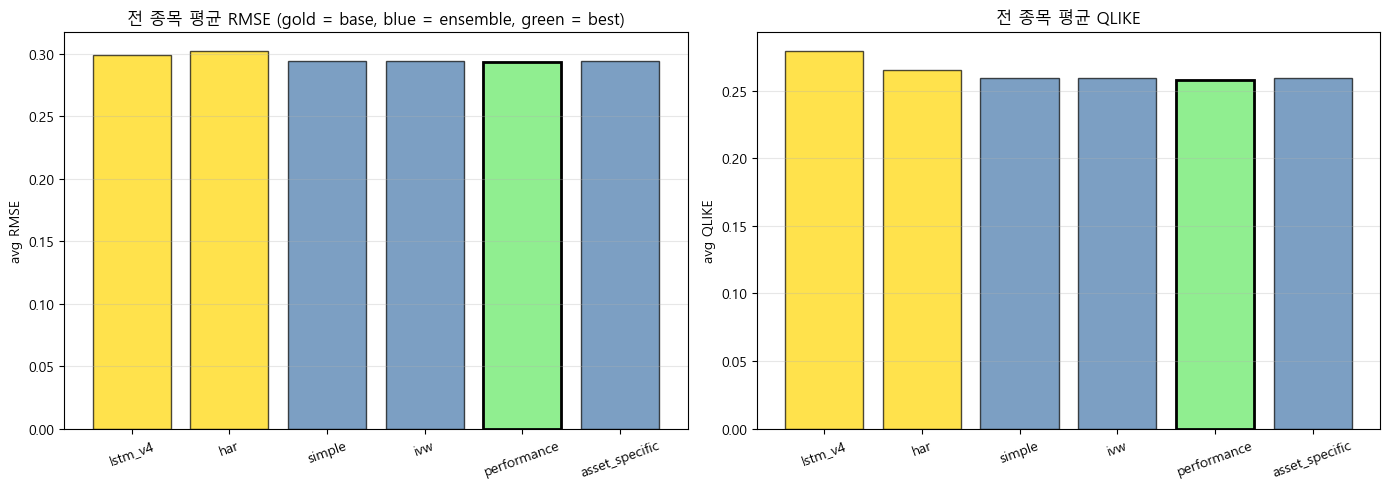

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
ax = axes[0]
avg_rmses = [np.mean([all_summary[tk][m]['rmse']['mean'] for tk in TICKERS]) for m in MODELS_FULL]
colors = ['gold' if 'lstm' in m or m == 'har' else '#4477AA' for m in MODELS_FULL]
ax.bar(MODELS_FULL, avg_rmses, color=colors, alpha=0.7, edgecolor='black')
best_i = int(np.argmin(avg_rmses))
ax.bar(MODELS_FULL[best_i], avg_rmses[best_i], color='lightgreen', edgecolor='black', linewidth=2)
ax.set_title('전 종목 평균 RMSE (gold = base, blue = ensemble, green = best)')
ax.set_ylabel('avg RMSE')
ax.tick_params(axis='x', rotation=20)
ax.grid(alpha=0.3, axis='y')

# QLIKE
ax = axes[1]
avg_qlikes = [np.mean([all_summary[tk][m]['qlike']['mean'] for tk in TICKERS]) for m in MODELS_FULL]
ax.bar(MODELS_FULL, avg_qlikes, color=colors, alpha=0.7, edgecolor='black')
best_q = int(np.argmin(avg_qlikes))
ax.bar(MODELS_FULL[best_q], avg_qlikes[best_q], color='lightgreen', edgecolor='black', linewidth=2)
ax.set_title('전 종목 평균 QLIKE')
ax.set_ylabel('avg QLIKE')
ax.tick_params(axis='x', rotation=20)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### §7.B. 종목별 RMSE Heatmap (6 모델)


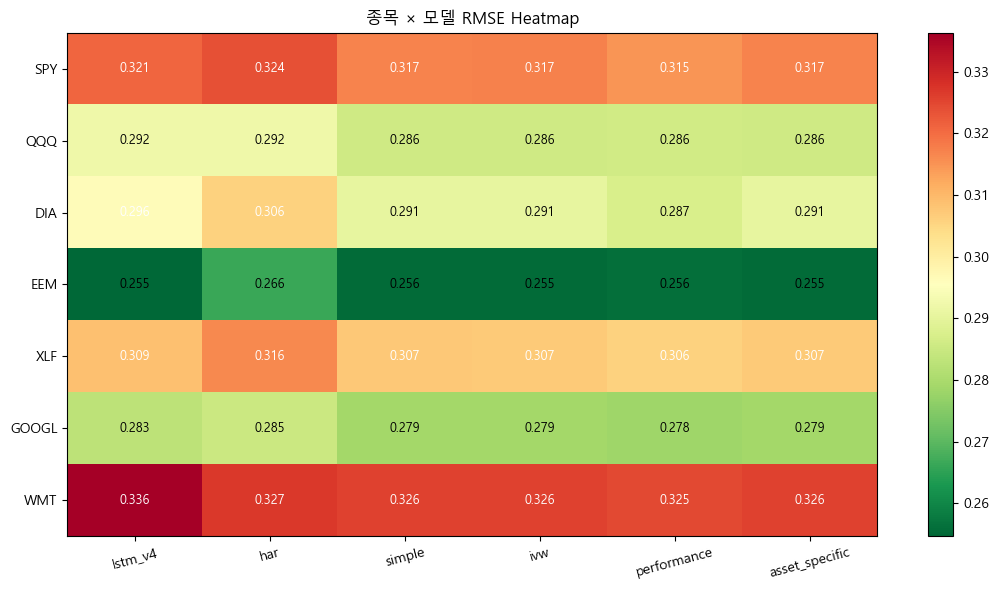

In [9]:
rmse_matrix = np.zeros((len(TICKERS), len(MODELS_FULL)))
for i, tk in enumerate(TICKERS):
    for j, m in enumerate(MODELS_FULL):
        rmse_matrix[i, j] = all_summary[tk][m]['rmse']['mean']

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(rmse_matrix, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(MODELS_FULL)))
ax.set_xticklabels(MODELS_FULL, rotation=15)
ax.set_yticks(range(len(TICKERS)))
ax.set_yticklabels(TICKERS)
for i in range(len(TICKERS)):
    for j in range(len(MODELS_FULL)):
        ax.text(j, i, f'{rmse_matrix[i,j]:.3f}', ha='center', va='center',
                color='white' if rmse_matrix[i,j] > rmse_matrix.mean() else 'black', fontsize=9)
ax.set_title('종목 × 모델 RMSE Heatmap')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### §7.C. 종목별 6 모델 비교 (각 종목 panel)


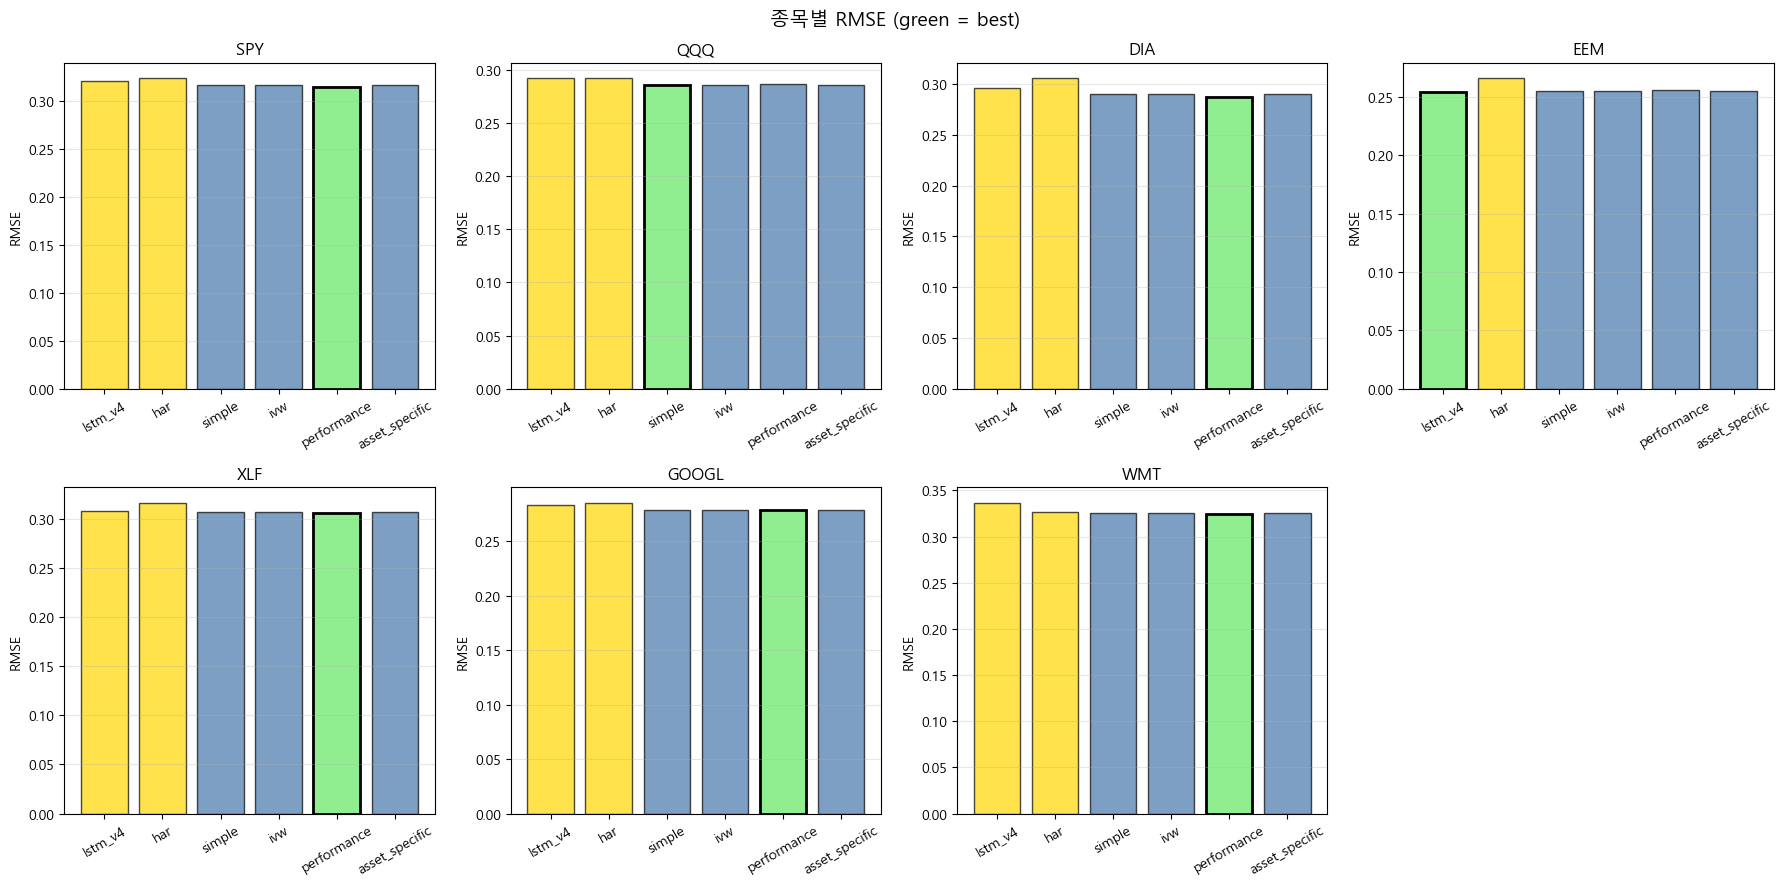

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, tk in enumerate(TICKERS):
    ax = axes[i]
    rmses = [all_summary[tk][m]['rmse']['mean'] for m in MODELS_FULL]
    colors_local = ['gold' if 'lstm' in m or m == 'har' else '#4477AA' for m in MODELS_FULL]
    ax.bar(MODELS_FULL, rmses, color=colors_local, alpha=0.7, edgecolor='black')
    best_i = int(np.argmin(rmses))
    ax.bar(MODELS_FULL[best_i], rmses[best_i], color='lightgreen', edgecolor='black', linewidth=2)
    ax.set_title(f'{tk}')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3, axis='y')
for j in range(len(TICKERS), len(axes)):
    axes[j].axis('off')
plt.suptitle('종목별 RMSE (green = best)', fontsize=14)
plt.tight_layout()
plt.show()


### §7.D. DM 검정 결과 Heatmap (vs v4, vs HAR)


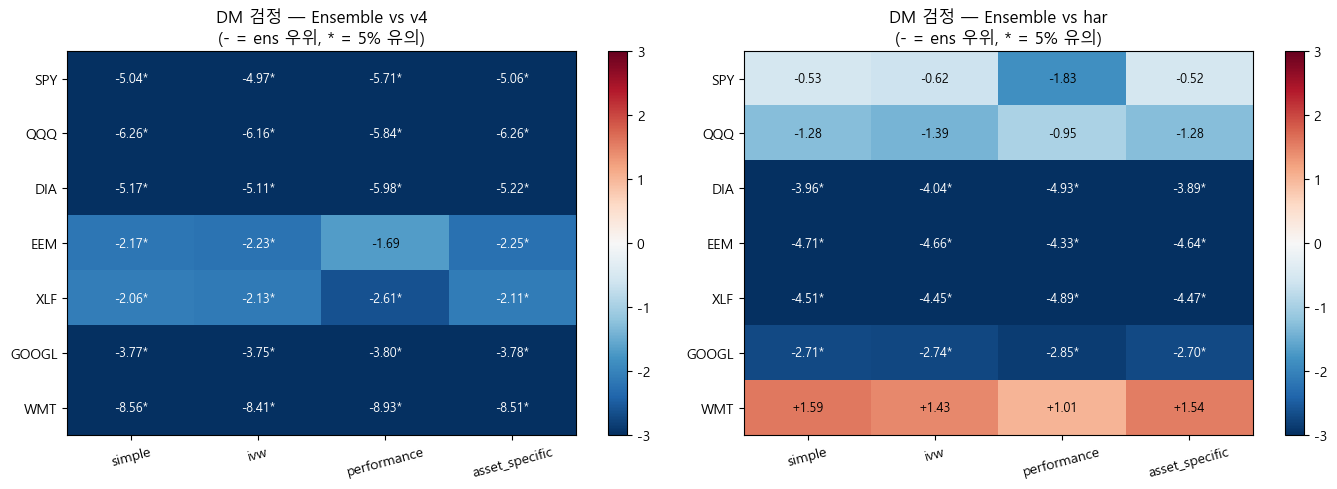

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, vs_target in enumerate(['vs_v4', 'vs_har']):
    ax = axes[ax_idx]
    dm_matrix = np.zeros((len(TICKERS), len(WEIGHT_FUNCS)))
    for i, tk in enumerate(TICKERS):
        for j, v_name in enumerate(WEIGHT_FUNCS):
            dm_matrix[i, j] = dm_results[tk][v_name][vs_target]['DM']
    im = ax.imshow(dm_matrix, cmap='RdBu_r', vmin=-3, vmax=3, aspect='auto')
    for i in range(len(TICKERS)):
        for j, v_name in enumerate(WEIGHT_FUNCS):
            p = dm_results[TICKERS[i]][v_name][vs_target]['p_value']
            text = f'{dm_matrix[i,j]:+.2f}'
            if p < 0.05: text += '*'
            ax.text(j, i, text, ha='center', va='center',
                    color='white' if abs(dm_matrix[i,j]) > 2 else 'black', fontsize=9)
    ax.set_xticks(range(len(WEIGHT_FUNCS)))
    ax.set_xticklabels(list(WEIGHT_FUNCS.keys()), rotation=15)
    ax.set_yticks(range(len(TICKERS)))
    ax.set_yticklabels(TICKERS)
    ax.set_title(f'DM 검정 — Ensemble {vs_target.replace("_", " ")}\n(- = ens 우위, * = 5% 유의)')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### §7.E. Ensemble 가중치 분포 (변형별)


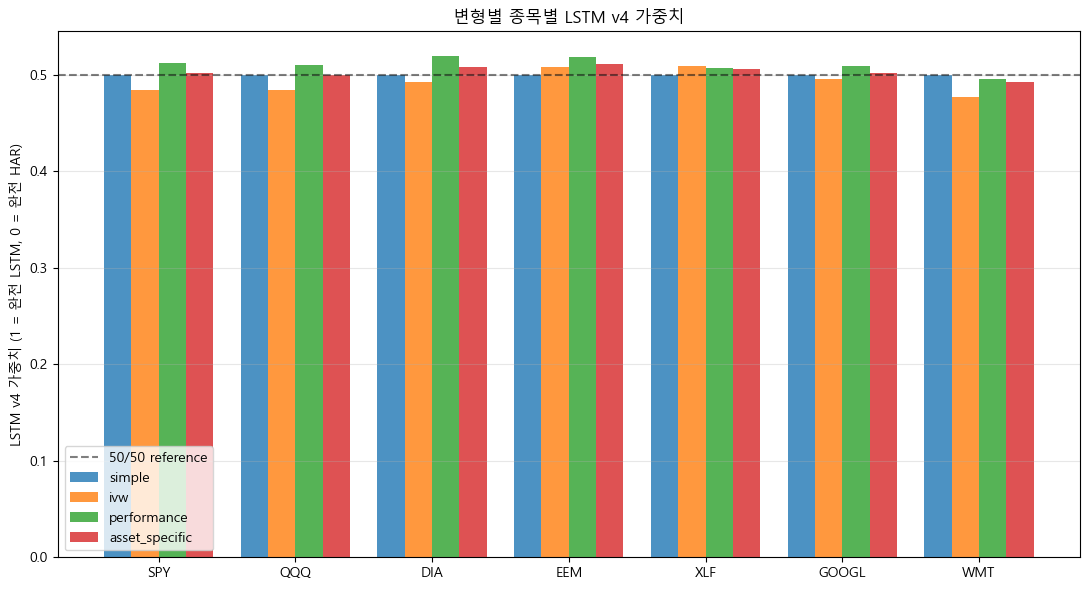

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(TICKERS))
width = 0.2
for i, v_name in enumerate(WEIGHT_FUNCS):
    weights = []
    for tk in TICKERS:
        n_folds = len(base_results[tk]['lstm_v4_folds'])
        w_v4, _ = WEIGHT_FUNCS[v_name](tk, n_folds)
        weights.append(w_v4.mean())
    offset = (i - 1.5) * width
    ax.bar(x + offset, weights, width, label=v_name, alpha=0.8)
ax.axhline(0.5, color='black', ls='--', alpha=0.5, label='50/50 reference')
ax.set_xticks(x)
ax.set_xticklabels(TICKERS)
ax.set_ylabel('LSTM v4 가중치 (1 = 완전 LSTM, 0 = 완전 HAR)')
ax.set_title('변형별 종목별 LSTM v4 가중치')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## §8. 결론 + 보고서 자동 생성


In [13]:
# 저장
OUT_DIR = RESULTS_DIR / 'lstm_ensemble'
OUT_DIR.mkdir(parents=True, exist_ok=True)


# 종목 × 변형 비교 CSV
rows = []
for tk in TICKERS:
    for m in MODELS_FULL:
        s = all_summary[tk][m]
        rows.append({
            'ticker': tk, 'model': m,
            'rmse': s['rmse']['mean'], 'qlike': s['qlike']['mean'],
            'r2_train_mean': s['r2_train_mean']['mean'] if not np.isnan(s['r2_train_mean']['mean']) else None,
            'pred_std_ratio': s['pred_std_ratio']['mean'],
            'mae': s['mae']['mean'],
        })
df_comp = pd.DataFrame(rows)
csv_path = OUT_DIR / 'ensemble_comparison.csv'
df_comp.to_csv(csv_path, index=False)
print(f'저장: {csv_path}')


# Best 모델 식별 (전 종목 평균 기준)
avg_rmses = {m: np.mean([all_summary[tk][m]['rmse']['mean'] for tk in TICKERS]) for m in MODELS_FULL}
avg_qlikes = {m: np.mean([all_summary[tk][m]['qlike']['mean'] for tk in TICKERS]) for m in MODELS_FULL}
best_rmse_model  = min(avg_rmses, key=avg_rmses.get)
best_qlike_model = min(avg_qlikes, key=avg_qlikes.get)


# 보고서 자동 생성
report_path = RESULTS_DIR / 'ensemble_report.md'
lines = []
lines.append('# Phase 1.5 v8 — Ensemble Evaluation 보고서')
lines.append('')
lines.append('> v4 best LSTM + HAR-RV 의 4 ensemble 변형 비교')
lines.append('> 학습 X — 기존 fold_predictions 의 가중 평균만 계산')
lines.append('')

lines.append('## 1. 전 종목 평균 메트릭')
lines.append('')
lines.append('| 모델 | avg RMSE | avg QLIKE | avg PSR |')
lines.append('|---|---|---|---|')
for m in MODELS_FULL:
    avg_p = np.mean([all_summary[tk][m]['pred_std_ratio']['mean'] for tk in TICKERS])
    marker_r = ' ⭐' if m == best_rmse_model else ''
    marker_q = ' ⭐' if m == best_qlike_model else ''
    lines.append(f'| {m} | {avg_rmses[m]:.4f}{marker_r} | {avg_qlikes[m]:.4f}{marker_q} | {avg_p:.4f} |')
lines.append('')
lines.append(f'**RMSE best: {best_rmse_model}** | **QLIKE best: {best_qlike_model}**')
lines.append('')

lines.append('## 2. 종목 × 모델 RMSE 표')
lines.append('')
header_md = '| ticker |'
for m in MODELS_FULL:
    header_md += f' {m} |'
header_md += ' best |'
lines.append(header_md)
lines.append('|' + '---|' * (len(MODELS_FULL) + 2))
for tk in TICKERS:
    row = f'| {tk}'
    rmses = []
    for m in MODELS_FULL:
        r = all_summary[tk][m]['rmse']['mean']
        rmses.append(r)
        row += f' | {r:.4f}'
    best_i = int(np.argmin(rmses))
    row += f' | **{MODELS_FULL[best_i]}** |'
    lines.append(row)
lines.append('')

lines.append('## 3. DM 검정 (Ensemble vs v4 / HAR)')
lines.append('')
lines.append('| ticker | variant | DM vs v4 | p_v4 | DM vs HAR | p_har |')
lines.append('|---|---|---|---|---|---|')
for tk in TICKERS:
    for v_name in WEIGHT_FUNCS:
        dm_v4 = dm_results[tk][v_name]['vs_v4']
        dm_har = dm_results[tk][v_name]['vs_har']
        sig_v4 = '✓' if dm_v4['p_value'] < 0.05 else ' '
        sig_har = '✓' if dm_har['p_value'] < 0.05 else ' '
        lines.append(f'| {tk} | {v_name} | {dm_v4["DM"]:+.2f}{sig_v4} | {dm_v4["p_value"]:.2e} '
                     f'| {dm_har["DM"]:+.2f}{sig_har} | {dm_har["p_value"]:.2e} |')
lines.append('')

lines.append('## 4. Best 모델별 종목 카운트')
lines.append('')
best_counts = {m: 0 for m in MODELS_FULL}
for tk in TICKERS:
    rmses = [all_summary[tk][m]['rmse']['mean'] for m in MODELS_FULL]
    best_i = int(np.argmin(rmses))
    best_counts[MODELS_FULL[best_i]] += 1
lines.append('| 모델 | best 종목 수 |')
lines.append('|---|---|')
for m, c in sorted(best_counts.items(), key=lambda x: -x[1]):
    lines.append(f'| {m} | {c}/7 |')
lines.append('')

lines.append('## 5. 결론')
lines.append('')
if best_rmse_model in WEIGHT_FUNCS:
    lines.append(f'**Ensemble 변형 ({best_rmse_model}) 가 단일 모델 (v4, HAR) 대비 평균 RMSE 우수.**')
    lines.append('')
    lines.append('→ BL 통합 시 ensemble 권고')
else:
    lines.append(f'**단일 모델 ({best_rmse_model}) 이 ensemble 보다 평균 RMSE 우수.**')
    lines.append('')
    lines.append('→ Asset-Specific Selection 또는 특정 ensemble 변형 검토')
lines.append('')

with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print(f'저장: {report_path}')


print()
print('=' * 80)
print('Phase 1.5 v8 — Ensemble Evaluation 완료')
print('=' * 80)
print(f'\nBest RMSE 모델 (전 종목 평균): {best_rmse_model} ({avg_rmses[best_rmse_model]:.4f})')
print(f'Best QLIKE 모델: {best_qlike_model} ({avg_qlikes[best_qlike_model]:.4f})')
print()
print('종목별 best:')
for tk in TICKERS:
    rmses = [all_summary[tk][m]['rmse']['mean'] for m in MODELS_FULL]
    best_i = int(np.argmin(rmses))
    print(f'  {tk:<8} → {MODELS_FULL[best_i]} (RMSE {rmses[best_i]:.4f})')


저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\lstm_ensemble\ensemble_comparison.csv
저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\ensemble_report.md

Phase 1.5 v8 — Ensemble Evaluation 완료

Best RMSE 모델 (전 종목 평균): performance (0.2934)
Best QLIKE 모델: performance (0.2582)

종목별 best:
  SPY      → performance (RMSE 0.3148)
  QQQ      → simple (RMSE 0.2858)
  DIA      → performance (RMSE 0.2874)
  EEM      → lstm_v4 (RMSE 0.2546)
  XLF      → performance (RMSE 0.3060)
  GOOGL    → performance (RMSE 0.2785)
  WMT      → performance (RMSE 0.3246)
